In [ ]:
# Upload your kaggle.json API key
from google.colab import files
files.upload()  # A button will appear — upload your kaggle.json file

# Move it to the right folder so Kaggle API can find it
import os
os.makedirs("/root/.kaggle", exist_ok=True)
os.rename("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 600)

print("✅ Kaggle API key set up successfully!")

TypeError: 'NoneType' object is not subscriptable

In [ ]:
# Download the Food-101 dataset from Kaggle
os.system("kaggle datasets download -d dansbecker/food-101")

print("✅ Dataset downloaded!")

In [ ]:
import zipfile

# Unzip the dataset
with zipfile.ZipFile("food-101.zip", "r") as zip_ref:
    zip_ref.extractall("food-101")

print("✅ Dataset unzipped!")

In [ ]:
import os

import os

# Let's see what food categories we have
food_list = os.listdir("food-101/food-101/images")
print(f"✅ Total food categories: {len(food_list)}")
print(f"📋 First 10 categories: {food_list[:10]}")


In [ ]:
# Let's explore the actual folder structure
import os

for root, dirs, files in os.walk("food-101"):
    level = root.replace("food-101", "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:  # Only go 2 levels deep so it's not too long
        subindent = " " * 2 * (level + 1)
        for file in files[:3]:  # Show max 3 files per folder
            print(f"{subindent}{file}")

In [ ]:
# Fixed path
food_list = os.listdir("food-101/food-101/food-101/images")
print(f"✅ Total food categories: {len(food_list)}")
print(f"📋 First 10 categories: {food_list[:10]}")

In [ ]:
# Set the base image path — we'll use this everywhere from now on
IMAGE_PATH = "food-101/food-101/food-101/images"
META_PATH = "food-101/food-101/food-101/meta"

print(f"✅ Image path set: {IMAGE_PATH}")
print(f"✅ Meta path set: {META_PATH}")

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import os

# Pick 9 random food categories
categories = os.listdir(IMAGE_PATH)
selected = random.sample(categories, 9)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
fig.suptitle("🍽️ Food-101 Sample Images", fontsize=16)

for ax, category in zip(axes.flatten(), selected):
    # Pick a random image from that category
    img_folder = os.path.join(IMAGE_PATH, category)
    img_file = random.choice(os.listdir(img_folder))
    img_path = os.path.join(img_folder, img_file)

    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.set_title(category.replace("_", " ").title(), fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

print(f"✅ TensorFlow version: {tf.__version__}")
print(f"✅ GPU available: {tf.config.list_physical_devices('GPU')}")

In [ ]:
IMG_SIZE = 224      # MobileNetV2 expects 224x224 images
BATCH_SIZE = 32     # How many images to process at once
NUM_CLASSES = 101   # 101 food categories

# This automatically loads images from folders, resizes them,
# and splits them into training (80%) and validation (20%)
datagen = ImageDataGenerator(
    rescale=1./255,          # Normalize pixels from 0-255 to 0-1
    validation_split=0.2,    # 20% of data used for validation
    horizontal_flip=True,    # Randomly flip images (data augmentation)
    zoom_range=0.2,          # Randomly zoom in/out
    rotation_range=15        # Randomly rotate slightly
)

# Training set
train_data = datagen.flow_from_directory(
    IMAGE_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

# Validation set
val_data = datagen.flow_from_directory(
    IMAGE_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

print(f"✅ Training images: {train_data.samples}")
print(f"✅ Validation images: {val_data.samples}")

In [ ]:
# Load MobileNetV2 pre-trained on ImageNet, without the top classification layer
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,        # We'll add our own top layer for 101 food classes
    weights="imagenet"        # Start with weights trained on 1M+ images
)

# Freeze the base model — we don't want to change its learned features yet
base_model.trainable = False

# Build our custom top on top of MobileNetV2
x = base_model.output
x = GlobalAveragePooling2D()(x)       # Flatten the features
x = Dropout(0.3)(x)                   # Randomly drop neurons to prevent overfitting
x = Dense(256, activation="relu")(x)  # A fully connected layer
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)  # Final layer: 101 food classes

model = Model(inputs=base_model.input, outputs=output)

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("✅ Model built successfully!")
print(f"📊 Total layers: {len(model.layers)}")
print(f"📊 Trainable parameters: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Stop training if accuracy stops improving
early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=3,               # Stop after 3 epochs with no improvement
    restore_best_weights=True
)

# Reduce learning rate if we hit a plateau
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,               # Cut learning rate in half
    patience=2,
    min_lr=1e-6
)

print("🚀 Starting training... this will take 20-40 minutes on GPU")
print("📊 Watch the val_accuracy — that's the important number!\n")

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

In [ ]:
# Smaller image size = much faster training, slightly less accuracy
IMG_SIZE = 96  # Down from 224 — big speed boost!

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    rotation_range=15
)

train_data = datagen.flow_from_directory(
    IMAGE_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=64,             # Bigger batch = faster
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_data = datagen.flow_from_directory(
    IMAGE_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=64,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

print("✅ Data ready!")

In [ ]:
# Rebuild model with new image size
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    steps_per_epoch=100,    # ✅ 100 steps only
    validation_steps=30,    # ✅ 30 validation steps
    callbacks=[early_stop, reduce_lr]
)

In [ ]:
# Unfreeze the last 30 layers of MobileNetV2 for fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False  # Keep early layers frozen

# Recompile with a much lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),  # 10x smaller lr
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop2 = EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True)
reduce_lr2 = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7)

print("🔥 Fine-tuning started...")

history2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    steps_per_epoch=150,   # A bit more steps this time
    validation_steps=50,
    callbacks=[early_stop2, reduce_lr2]
)

In [ ]:
# Save the trained model
model.save("food_classifier.h5")
print("✅ Model saved!")

# Get the class labels in the correct order
class_labels = list(train_data.class_indices.keys())
print(f"✅ {len(class_labels)} food labels loaded")

# Calorie map (per 100g / per average serving)
calorie_map = {
    "apple_pie": 237, "baby_back_ribs": 320, "baklava": 428,
    "beef_carpaccio": 150, "beef_tartare": 196, "beet_salad": 85,
    "beignets": 320, "bibimbap": 210, "bread_pudding": 250,
    "breakfast_burrito": 305, "bruschetta": 180, "caesar_salad": 190,
    "cannoli": 297, "caprese_salad": 140, "carrot_cake": 415,
    "ceviche": 130, "cheesecake": 321, "cheese_plate": 350,
    "chicken_curry": 240, "chicken_quesadilla": 290, "chicken_wings": 290,
    "chocolate_cake": 350, "chocolate_mousse": 280, "churros": 370,
    "clam_chowder": 165, "club_sandwich": 390, "crab_cakes": 185,
    "creme_brulee": 332, "croque_madame": 410, "cup_cakes": 305,
    "deviled_eggs": 145, "donuts": 452, "dumplings": 190,
    "edamame": 120, "eggs_benedict": 350, "escargots": 130,
    "falafel": 330, "filet_mignon": 280, "fish_and_chips": 520,
    "foie_gras": 460, "french_fries": 365, "french_onion_soup": 180,
    "french_toast": 230, "fried_calamari": 175, "fried_rice": 238,
    "frozen_yogurt": 159, "garlic_bread": 350, "gnocchi": 250,
    "greek_salad": 115, "grilled_cheese_sandwich": 400, "grilled_salmon": 208,
    "guacamole": 150, "gyoza": 210, "hamburger": 354,
    "hot_and_sour_soup": 95, "hot_dog": 290, "huevos_rancheros": 310,
    "hummus": 170, "ice_cream": 207, "lasagna": 310,
    "lobster_bisque": 220, "lobster_roll_sandwich": 436, "macaroni_and_cheese": 310,
    "macarons": 400, "miso_soup": 84, "mussels": 172,
    "nachos": 346, "onion_rings": 411, "oysters": 81,
    "pad_thai": 357, "paella": 280, "pancakes": 227,
    "panna_cotta": 230, "peking_duck": 337, "pho": 215,
    "pizza": 266, "pork_chop": 231, "prime_rib": 400,
    "pulled_pork_sandwich": 430, "poutine": 740, "ramen": 436,
    "ravioli": 220, "red_velvet_cake": 367, "risotto": 166,
    "samosa": 308, "sashimi": 127, "scallops": 111,
    "seaweed_salad": 70, "shrimp_and_grits": 280, "spaghetti_bolognese": 285,
    "spaghetti_carbonara": 370, "spring_rolls": 165, "steak": 271,
    "strawberry_shortcake": 245, "sushi": 150, "tacos": 226,
    "takoyaki": 200, "tiramisu": 240, "tuna_tartare": 144,
    "waffles": 291
}

print("✅ Calorie map loaded!")

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

def predict_calories(img_path):
    # Load and preprocess the image
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    predictions = model.predict(img_array, verbose=0)
    top3_indices = np.argsort(predictions[0])[::-1][:3]

    print("🍽️ Top 3 Predictions:")
    print("-" * 35)
    for i, idx in enumerate(top3_indices):
        food = class_labels[idx]
        confidence = predictions[0][idx] * 100
        calories = calorie_map.get(food, "N/A")
        print(f"{i+1}. {food.replace('_', ' ').title()}")
        print(f"   Confidence : {confidence:.1f}%")
        print(f"   Calories   : {calories} kcal")
        print()

print("✅ Prediction function ready!")

In [ ]:
from google.colab import files
import shutil

# Upload your photo
uploaded = files.upload()

# Get the filename
img_path = list(uploaded.keys())[0]
print(f"✅ Image uploaded: {img_path}")

# Show the image
plt.figure(figsize=(5, 5))
img_display = mpimg.imread(img_path)
plt.imshow(img_display)
plt.axis("off")
plt.title("Your Meal 🍽️", fontsize=14)
plt.show()

# Run prediction!
predict_calories(img_path)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive mounted!")

In [ ]:
from google.colab import files
files.upload()  # upload kaggle.json

import os
os.makedirs("/root/.kaggle", exist_ok=True)
os.rename("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 600)

os.system("kaggle datasets download -d dansbecker/food-101")
print("✅ Downloaded!")

In [ ]:
import zipfile
with zipfile.ZipFile("food-101.zip", "r") as zip_ref:
    zip_ref.extractall("food-101")
print("✅ Unzipped!")

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

IMG_SIZE = 224       # ✅ Full size this time (was 96 before)
BATCH_SIZE = 32
NUM_CLASSES = 101
IMAGE_PATH = "food-101/food-101/food-101/images"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    rotation_range=20,
    width_shift_range=0.2,   # ✅ New augmentation
    height_shift_range=0.2,  # ✅ New augmentation
    shear_range=0.15,        # ✅ New augmentation
    fill_mode='nearest'
)

train_data = datagen.flow_from_directory(
    IMAGE_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_data = datagen.flow_from_directory(
    IMAGE_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

print(f"✅ Training images: {train_data.samples}")
print(f"✅ Validation images: {val_data.samples}")

In [ ]:
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze only the first 100 layers
for layer in base_model.layers[:100]:
    layer.trainable = False
for layer in base_model.layers[100:]:
    layer.trainable = True  # ✅ Train more layers than before

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)       # ✅ New — stabilizes training
x = Dense(512, activation="relu")(x)  # ✅ Bigger layer than before (was 256)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(256, activation="relu")(x)  # ✅ Extra layer
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("✅ Model built!")
print(f"📊 Trainable parameters: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")

NameError: name 'MobileNetV2' is not defined

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=5,                # ✅ More patience than before (was 3)
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-7
)

# ✅ Save best model automatically to Google Drive
checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/food_model_best.h5",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

print("🚀 Training started — this will take 2-3 hours, let it run!")
print("📊 Model is being saved to Google Drive automatically\n")

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,                 # ✅ More epochs
    steps_per_epoch=500,       # ✅ Way more steps (was 100-150)
    validation_steps=100,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

🚀 Training started — this will take 2-3 hours, let it run!
📊 Model is being saved to Google Drive automatically



NameError: name 'model' is not defined

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/food_model_best.h5")
print("✅ Best model loaded from Drive!")

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/content/drive/MyDrive/food_model_best.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from tensorflow.keras.preprocessing import image

IMG_SIZE = 224

class_labels = list(train_data.class_indices.keys())

calorie_map = {
    "apple_pie": 237, "baby_back_ribs": 320, "baklava": 428,
    "beef_carpaccio": 150, "beef_tartare": 196, "beet_salad": 85,
    "beignets": 320, "bibimbap": 210, "bread_pudding": 250,
    "breakfast_burrito": 305, "bruschetta": 180, "caesar_salad": 190,
    "cannoli": 297, "caprese_salad": 140, "carrot_cake": 415,
    "ceviche": 130, "cheesecake": 321, "cheese_plate": 350,
    "chicken_curry": 240, "chicken_quesadilla": 290, "chicken_wings": 290,
    "chocolate_cake": 350, "chocolate_mousse": 280, "churros": 370,
    "clam_chowder": 165, "club_sandwich": 390, "crab_cakes": 185,
    "creme_brulee": 332, "croque_madame": 410, "cup_cakes": 305,
    "deviled_eggs": 145, "donuts": 452, "dumplings": 190,
    "edamame": 120, "eggs_benedict": 350, "escargots": 130,
    "falafel": 330, "filet_mignon": 280, "fish_and_chips": 520,
    "foie_gras": 460, "french_fries": 365, "french_onion_soup": 180,
    "french_toast": 230, "fried_calamari": 175, "fried_rice": 238,
    "frozen_yogurt": 159, "garlic_bread": 350, "gnocchi": 250,
    "greek_salad": 115, "grilled_cheese_sandwich": 400, "grilled_salmon": 208,
    "guacamole": 150, "gyoza": 210, "hamburger": 354,
    "hot_and_sour_soup": 95, "hot_dog": 290, "huevos_rancheros": 310,
    "hummus": 170, "ice_cream": 207, "lasagna": 310,
    "lobster_bisque": 220, "lobster_roll_sandwich": 436, "macaroni_and_cheese": 310,
    "macarons": 400, "miso_soup": 84, "mussels": 172,
    "nachos": 346, "onion_rings": 411, "oysters": 81,
    "pad_thai": 357, "paella": 280, "pancakes": 227,
    "panna_cotta": 230, "peking_duck": 337, "pho": 215,
    "pizza": 266, "pork_chop": 231, "prime_rib": 400,
    "pulled_pork_sandwich": 430, "poutine": 740, "ramen": 436,
    "ravioli": 220, "red_velvet_cake": 367, "risotto": 166,
    "samosa": 308, "sashimi": 127, "scallops": 111,
    "seaweed_salad": 70, "shrimp_and_grits": 280, "spaghetti_bolognese": 285,
    "spaghetti_carbonara": 370, "spring_rolls": 165, "steak": 271,
    "strawberry_shortcake": 245, "sushi": 150, "tacos": 226,
    "takoyaki": 200, "tiramisu": 240, "tuna_tartare": 144,
    "waffles": 291
}

def predict_calories(img_path):
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array, verbose=0)
    top3_indices = np.argsort(predictions[0])[::-1][:3]

    # Show the image
    plt.figure(figsize=(4, 4))
    plt.imshow(image.load_img(img_path))
    plt.axis("off")
    plt.title("Your Meal 🍽️")
    plt.show()

    print("🍽️ Top 3 Predictions:")
    print("-" * 35)
    for i, idx in enumerate(top3_indices):
        food = class_labels[idx]
        confidence = predictions[0][idx] * 100
        calories = calorie_map.get(food, "N/A")
        print(f"{i+1}. {food.replace('_', ' ').title()}")
        print(f"   Confidence : {confidence:.1f}%")
        print(f"   Calories   : {calories} kcal")
        print()

print("✅ Ready to predict!")

In [ ]:
from google.colab import files
uploaded = files.upload()
img_path = list(uploaded.keys())[0]
predict_calories(img_path)

Saving Classic-Glazed-Donutsrex-kpzb-googleFourByThree.jpg to Classic-Glazed-Donutsrex-kpzb-googleFourByThree.jpg


NameError: name 'predict_calories' is not defined

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from tensorflow.keras.models import load_model
model = load_model("/content/drive/MyDrive/food_model_best.h5")
print("✅ Model loaded!")

Mounted at /content/drive


✅ Model loaded!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

IMG_SIZE = 224

# Manually define class labels (alphabetical order)
class_labels = [
    "apple_pie", "baby_back_ribs", "baklava", "beef_carpaccio", "beef_tartare",
    "beet_salad", "beignets", "bibimbap", "bread_pudding", "breakfast_burrito",
    "bruschetta", "caesar_salad", "cannoli", "caprese_salad", "carrot_cake",
    "ceviche", "cheesecake", "cheese_plate", "chicken_curry", "chicken_quesadilla",
    "chicken_wings", "chocolate_cake", "chocolate_mousse", "churros", "clam_chowder",
    "club_sandwich", "crab_cakes", "creme_brulee", "croque_madame", "cup_cakes",
    "deviled_eggs", "donuts", "dumplings", "edamame", "eggs_benedict",
    "escargots", "falafel", "filet_mignon", "fish_and_chips", "foie_gras",
    "french_fries", "french_onion_soup", "french_toast", "fried_calamari", "fried_rice",
    "frozen_yogurt", "garlic_bread", "gnocchi", "greek_salad", "grilled_cheese_sandwich",
    "grilled_salmon", "guacamole", "gyoza", "hamburger", "hot_and_sour_soup",
    "hot_dog", "huevos_rancheros", "hummus", "ice_cream", "lasagna",
    "lobster_bisque", "lobster_roll_sandwich", "macaroni_and_cheese", "macarons", "miso_soup",
    "mussels", "nachos", "onion_rings", "oysters", "pad_thai",
    "paella", "pancakes", "panna_cotta", "peking_duck", "pho",
    "pizza", "pork_chop", "prime_rib", "pulled_pork_sandwich", "poutine",
    "ramen", "ravioli", "red_velvet_cake", "risotto", "samosa",
    "sashimi", "scallops", "seaweed_salad", "shrimp_and_grits", "spaghetti_bolognese",
    "spaghetti_carbonara", "spring_rolls", "steak", "strawberry_shortcake", "sushi",
    "tacos", "takoyaki", "tiramisu", "tuna_tartare", "waffles"
]

calorie_map = {
    "apple_pie": 237, "baby_back_ribs": 320, "baklava": 428,
    "beef_carpaccio": 150, "beef_tartare": 196, "beet_salad": 85,
    "beignets": 320, "bibimbap": 210, "bread_pudding": 250,
    "breakfast_burrito": 305, "bruschetta": 180, "caesar_salad": 190,
    "cannoli": 297, "caprese_salad": 140, "carrot_cake": 415,
    "ceviche": 130, "cheesecake": 321, "cheese_plate": 350,
    "chicken_curry": 240, "chicken_quesadilla": 290, "chicken_wings": 290,
    "chocolate_cake": 350, "chocolate_mousse": 280, "churros": 370,
    "clam_chowder": 165, "club_sandwich": 390, "crab_cakes": 185,
    "creme_brulee": 332, "croque_madame": 410, "cup_cakes": 305,
    "deviled_eggs": 145, "donuts": 452, "dumplings": 190,
    "edamame": 120, "eggs_benedict": 350, "escargots": 130,
    "falafel": 330, "filet_mignon": 280, "fish_and_chips": 520,
    "foie_gras": 460, "french_fries": 365, "french_onion_soup": 180,
    "french_toast": 230, "fried_calamari": 175, "fried_rice": 238,
    "frozen_yogurt": 159, "garlic_bread": 350, "gnocchi": 250,
    "greek_salad": 115, "grilled_cheese_sandwich": 400, "grilled_salmon": 208,
    "guacamole": 150, "gyoza": 210, "hamburger": 354,
    "hot_and_sour_soup": 95, "hot_dog": 290, "huevos_rancheros": 310,
    "hummus": 170, "ice_cream": 207, "lasagna": 310,
    "lobster_bisque": 220, "lobster_roll_sandwich": 436, "macaroni_and_cheese": 310,
    "macarons": 400, "miso_soup": 84, "mussels": 172,
    "nachos": 346, "onion_rings": 411, "oysters": 81,
    "pad_thai": 357, "paella": 280, "pancakes": 227,
    "panna_cotta": 230, "peking_duck": 337, "pho": 215,
    "pizza": 266, "pork_chop": 231, "prime_rib": 400,
    "pulled_pork_sandwich": 430, "poutine": 740, "ramen": 436,
    "ravioli": 220, "red_velvet_cake": 367, "risotto": 166,
    "samosa": 308, "sashimi": 127, "scallops": 111,
    "seaweed_salad": 70, "shrimp_and_grits": 280, "spaghetti_bolognese": 285,
    "spaghetti_carbonara": 370, "spring_rolls": 165, "steak": 271,
    "strawberry_shortcake": 245, "sushi": 150, "tacos": 226,
    "takoyaki": 200, "tiramisu": 240, "tuna_tartare": 144,
    "waffles": 291
}

def predict_calories(img_path):
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array, verbose=0)
    top3_indices = np.argsort(predictions[0])[::-1][:3]

    plt.figure(figsize=(4, 4))
    plt.imshow(image.load_img(img_path))
    plt.axis("off")
    plt.title("Your Meal 🍽️")
    plt.show()

    print("🍽️ Top 3 Predictions:")
    print("-" * 35)
    for i, idx in enumerate(top3_indices):
        food = class_labels[idx]
        confidence = predictions[0][idx] * 100
        calories = calorie_map.get(food, "N/A")
        print(f"{i+1}. {food.replace('_', ' ').title()}")
        print(f"   Confidence : {confidence:.1f}%")
        print(f"   Calories   : {calories} kcal")
        print()

print("✅ Everything ready!")

✅ Everything ready!


Saving 14140-baked-macaroni-and-cheese-ddmfs-0346-beauty-4x3-9b975d9c35f04f459a661405c1c85b7d.jpg to 14140-baked-macaroni-and-cheese-ddmfs-0346-beauty-4x3-9b975d9c35f04f459a661405c1c85b7d.jpg


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127869 (\N{FORK AND KNIFE WITH PLATE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


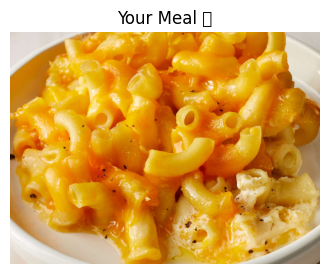

🍽️ Top 3 Predictions:
-----------------------------------
1. Macaroni And Cheese
   Confidence : 97.9%
   Calories   : 310 kcal

2. Pulled Pork Sandwich
   Confidence : 1.4%
   Calories   : 430 kcal

3. Gnocchi
   Confidence : 0.7%
   Calories   : 250 kcal



In [ ]:
from google.colab import files
uploaded = files.upload()  # choose any photo from your pc
img_path = list(uploaded.keys())[0]
predict_calories(img_path)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from tensorflow.keras.models import load_model
model = load_model("/content/drive/MyDrive/food_model_best.h5")
print("✅ Model loaded!")


Mounted at /content/drive


✅ Model loaded!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

IMG_SIZE = 224

# Manually define class labels (alphabetical order)
class_labels = [
    "apple_pie", "baby_back_ribs", "baklava", "beef_carpaccio", "beef_tartare",
    "beet_salad", "beignets", "bibimbap", "bread_pudding", "breakfast_burrito",
    "bruschetta", "caesar_salad", "cannoli", "caprese_salad", "carrot_cake",
    "ceviche", "cheesecake", "cheese_plate", "chicken_curry", "chicken_quesadilla",
    "chicken_wings", "chocolate_cake", "chocolate_mousse", "churros", "clam_chowder",
    "club_sandwich", "crab_cakes", "creme_brulee", "croque_madame", "cup_cakes",
    "deviled_eggs", "donuts", "dumplings", "edamame", "eggs_benedict",
    "escargots", "falafel", "filet_mignon", "fish_and_chips", "foie_gras",
    "french_fries", "french_onion_soup", "french_toast", "fried_calamari", "fried_rice",
    "frozen_yogurt", "garlic_bread", "gnocchi", "greek_salad", "grilled_cheese_sandwich",
    "grilled_salmon", "guacamole", "gyoza", "hamburger", "hot_and_sour_soup",
    "hot_dog", "huevos_rancheros", "hummus", "ice_cream", "lasagna",
    "lobster_bisque", "lobster_roll_sandwich", "macaroni_and_cheese", "macarons", "miso_soup",
    "mussels", "nachos", "onion_rings", "oysters", "pad_thai",
    "paella", "pancakes", "panna_cotta", "peking_duck", "pho",
    "pizza", "pork_chop", "prime_rib", "pulled_pork_sandwich", "poutine",
    "ramen", "ravioli", "red_velvet_cake", "risotto", "samosa",
    "sashimi", "scallops", "seaweed_salad", "shrimp_and_grits", "spaghetti_bolognese",
    "spaghetti_carbonara", "spring_rolls", "steak", "strawberry_shortcake", "sushi",
    "tacos", "takoyaki", "tiramisu", "tuna_tartare", "waffles"
]

calorie_map = {
    "apple_pie": 237, "baby_back_ribs": 320, "baklava": 428,
    "beef_carpaccio": 150, "beef_tartare": 196, "beet_salad": 85,
    "beignets": 320, "bibimbap": 210, "bread_pudding": 250,
    "breakfast_burrito": 305, "bruschetta": 180, "caesar_salad": 190,
    "cannoli": 297, "caprese_salad": 140, "carrot_cake": 415,
    "ceviche": 130, "cheesecake": 321, "cheese_plate": 350,
    "chicken_curry": 240, "chicken_quesadilla": 290, "chicken_wings": 290,
    "chocolate_cake": 350, "chocolate_mousse": 280, "churros": 370,
    "clam_chowder": 165, "club_sandwich": 390, "crab_cakes": 185,
    "creme_brulee": 332, "croque_madame": 410, "cup_cakes": 305,
    "deviled_eggs": 145, "donuts": 452, "dumplings": 190,
    "edamame": 120, "eggs_benedict": 350, "escargots": 130,
    "falafel": 330, "filet_mignon": 280, "fish_and_chips": 520,
    "foie_gras": 460, "french_fries": 365, "french_onion_soup": 180,
    "french_toast": 230, "fried_calamari": 175, "fried_rice": 238,
    "frozen_yogurt": 159, "garlic_bread": 350, "gnocchi": 250,
    "greek_salad": 115, "grilled_cheese_sandwich": 400, "grilled_salmon": 208,
    "guacamole": 150, "gyoza": 210, "hamburger": 354,
    "hot_and_sour_soup": 95, "hot_dog": 290, "huevos_rancheros": 310,
    "hummus": 170, "ice_cream": 207, "lasagna": 310,
    "lobster_bisque": 220, "lobster_roll_sandwich": 436, "macaroni_and_cheese": 310,
    "macarons": 400, "miso_soup": 84, "mussels": 172,
    "nachos": 346, "onion_rings": 411, "oysters": 81,
    "pad_thai": 357, "paella": 280, "pancakes": 227,
    "panna_cotta": 230, "peking_duck": 337, "pho": 215,
    "pizza": 266, "pork_chop": 231, "prime_rib": 400,
    "pulled_pork_sandwich": 430, "poutine": 740, "ramen": 436,
    "ravioli": 220, "red_velvet_cake": 367, "risotto": 166,
    "samosa": 308, "sashimi": 127, "scallops": 111,
    "seaweed_salad": 70, "shrimp_and_grits": 280, "spaghetti_bolognese": 285,
    "spaghetti_carbonara": 370, "spring_rolls": 165, "steak": 271,
    "strawberry_shortcake": 245, "sushi": 150, "tacos": 226,
    "takoyaki": 200, "tiramisu": 240, "tuna_tartare": 144,
    "waffles": 291
}

def predict_calories(img_path):
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array, verbose=0)
    top3_indices = np.argsort(predictions[0])[::-1][:3]

    plt.figure(figsize=(4, 4))
    plt.imshow(image.load_img(img_path))
    plt.axis("off")
    plt.title("Your Meal 🍽️")
    plt.show()

    print("🍽️ Top 3 Predictions:")
    print("-" * 35)
    for i, idx in enumerate(top3_indices):
        food = class_labels[idx]
        confidence = predictions[0][idx] * 100
        calories = calorie_map.get(food, "N/A")
        print(f"{i+1}. {food.replace('_', ' ').title()}")
        print(f"   Confidence : {confidence:.1f}%")
        print(f"   Calories   : {calories} kcal")
        print()

print("✅ Everything ready!")








✅ Everything ready!


Saving Classic-Glazed-Donutsrex-kpzb-googleFourByThree.jpg to Classic-Glazed-Donutsrex-kpzb-googleFourByThree.jpg


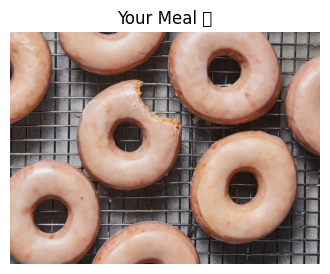

🍽️ Top 3 Predictions:
-----------------------------------
1. Donuts
   Confidence : 100.0%
   Calories   : 452 kcal

2. Oysters
   Confidence : 0.0%
   Calories   : 81 kcal

3. Cup Cakes
   Confidence : 0.0%
   Calories   : 305 kcal



In [ ]:
from google.colab import files
uploaded = files.upload()  # choose any photo from your pc
img_path = list(uploaded.keys())[0]
predict_calories(img_path)



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from tensorflow.keras.models import load_model
model = load_model("/content/drive/MyDrive/food_model_best.h5")
print("✅ Model loaded!")


Mounted at /content/drive


✅ Model loaded!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

IMG_SIZE = 224

# Manually define class labels (alphabetical order)
class_labels = [
    "apple_pie", "baby_back_ribs", "baklava", "beef_carpaccio", "beef_tartare",
    "beet_salad", "beignets", "bibimbap", "bread_pudding", "breakfast_burrito",
    "bruschetta", "caesar_salad", "cannoli", "caprese_salad", "carrot_cake",
    "ceviche", "cheesecake", "cheese_plate", "chicken_curry", "chicken_quesadilla",
    "chicken_wings", "chocolate_cake", "chocolate_mousse", "churros", "clam_chowder",
    "club_sandwich", "crab_cakes", "creme_brulee", "croque_madame", "cup_cakes",
    "deviled_eggs", "donuts", "dumplings", "edamame", "eggs_benedict",
    "escargots", "falafel", "filet_mignon", "fish_and_chips", "foie_gras",
    "french_fries", "french_onion_soup", "french_toast", "fried_calamari", "fried_rice",
    "frozen_yogurt", "garlic_bread", "gnocchi", "greek_salad", "grilled_cheese_sandwich",
    "grilled_salmon", "guacamole", "gyoza", "hamburger", "hot_and_sour_soup",
    "hot_dog", "huevos_rancheros", "hummus", "ice_cream", "lasagna",
    "lobster_bisque", "lobster_roll_sandwich", "macaroni_and_cheese", "macarons", "miso_soup",
    "mussels", "nachos", "onion_rings", "oysters", "pad_thai",
    "paella", "pancakes", "panna_cotta", "peking_duck", "pho",
    "pizza", "pork_chop", "prime_rib", "pulled_pork_sandwich", "poutine",
    "ramen", "ravioli", "red_velvet_cake", "risotto", "samosa",
    "sashimi", "scallops", "seaweed_salad", "shrimp_and_grits", "spaghetti_bolognese",
    "spaghetti_carbonara", "spring_rolls", "steak", "strawberry_shortcake", "sushi",
    "tacos", "takoyaki", "tiramisu", "tuna_tartare", "waffles"
]

calorie_map = {
    "apple_pie": 237, "baby_back_ribs": 320, "baklava": 428,
    "beef_carpaccio": 150, "beef_tartare": 196, "beet_salad": 85,
    "beignets": 320, "bibimbap": 210, "bread_pudding": 250,
    "breakfast_burrito": 305, "bruschetta": 180, "caesar_salad": 190,
    "cannoli": 297, "caprese_salad": 140, "carrot_cake": 415,
    "ceviche": 130, "cheesecake": 321, "cheese_plate": 350,
    "chicken_curry": 240, "chicken_quesadilla": 290, "chicken_wings": 290,
    "chocolate_cake": 350, "chocolate_mousse": 280, "churros": 370,
    "clam_chowder": 165, "club_sandwich": 390, "crab_cakes": 185,
    "creme_brulee": 332, "croque_madame": 410, "cup_cakes": 305,
    "deviled_eggs": 145, "donuts": 452, "dumplings": 190,
    "edamame": 120, "eggs_benedict": 350, "escargots": 130,
    "falafel": 330, "filet_mignon": 280, "fish_and_chips": 520,
    "foie_gras": 460, "french_fries": 365, "french_onion_soup": 180,
    "french_toast": 230, "fried_calamari": 175, "fried_rice": 238,
    "frozen_yogurt": 159, "garlic_bread": 350, "gnocchi": 250,
    "greek_salad": 115, "grilled_cheese_sandwich": 400, "grilled_salmon": 208,
    "guacamole": 150, "gyoza": 210, "hamburger": 354,
    "hot_and_sour_soup": 95, "hot_dog": 290, "huevos_rancheros": 310,
    "hummus": 170, "ice_cream": 207, "lasagna": 310,
    "lobster_bisque": 220, "lobster_roll_sandwich": 436, "macaroni_and_cheese": 310,
    "macarons": 400, "miso_soup": 84, "mussels": 172,
    "nachos": 346, "onion_rings": 411, "oysters": 81,
    "pad_thai": 357, "paella": 280, "pancakes": 227,
    "panna_cotta": 230, "peking_duck": 337, "pho": 215,
    "pizza": 266, "pork_chop": 231, "prime_rib": 400,
    "pulled_pork_sandwich": 430, "poutine": 740, "ramen": 436,
    "ravioli": 220, "red_velvet_cake": 367, "risotto": 166,
    "samosa": 308, "sashimi": 127, "scallops": 111,
    "seaweed_salad": 70, "shrimp_and_grits": 280, "spaghetti_bolognese": 285,
    "spaghetti_carbonara": 370, "spring_rolls": 165, "steak": 271,
    "strawberry_shortcake": 245, "sushi": 150, "tacos": 226,
    "takoyaki": 200, "tiramisu": 240, "tuna_tartare": 144,
    "waffles": 291
}

def predict_calories(img_path):
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array, verbose=0)
    top3_indices = np.argsort(predictions[0])[::-1][:3]

    plt.figure(figsize=(4, 4))
    plt.imshow(image.load_img(img_path))
    plt.axis("off")
    plt.title("Your Meal 🍽️")
    plt.show()

    print("🍽️ Top 3 Predictions:")
    print("-" * 35)
    for i, idx in enumerate(top3_indices):
        food = class_labels[idx]
        confidence = predictions[0][idx] * 100
        calories = calorie_map.get(food, "N/A")
        print(f"{i+1}. {food.replace('_', ' ').title()}")
        print(f"   Confidence : {confidence:.1f}%")
        print(f"   Calories   : {calories} kcal")
        print()

print("✅ Everything ready!")




✅ Everything ready!


Saving burger.jpg to burger.jpg


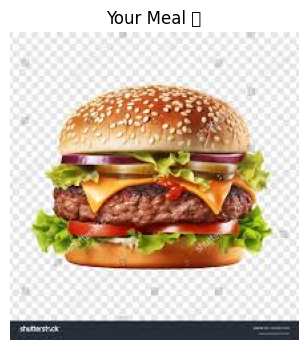

🍽️ Top 3 Predictions:
-----------------------------------
1. Hamburger
   Confidence : 99.2%
   Calories   : 354 kcal

2. Ramen
   Confidence : 0.7%
   Calories   : 436 kcal

3. Falafel
   Confidence : 0.0%
   Calories   : 330 kcal



In [ ]:
from google.colab import files
uploaded = files.upload()  # choose any photo from your pc
img_path = list(uploaded.keys())[0]
predict_calories(img_path)

